# Lecture 7: Introduction to Causal Abstraction

In this lecture, we will introduce the theory of **causal abstraction** - a framework for understanding when a simple causal process, e.g., a symbolic algorithm, faithfully describes a a more complex causal process, e.g., a neural network. 

### ✍ Learning goals

By the end of the lesson, we hope you take away the following.

* **Algorithms as causal models**: understand algorithms as causal models with variables, values, and mechanisms
* **Neural networks as causal models**: understand neural networks as causal models with variables, values, and mechanisms
* **Interchange interventions**: interventions that simulate the value a variable would have taken if a different input were provided 
* **Causal abstraction as implementation**: understand implementation as causal abstraction, where an algorithm is implemented when it abstracts the underlying system

In [ ]:
from IPython.display import clear_output
import plotly.io as pio

try:
    import google.colab
    is_colab = True
except ImportError:
    is_colab = False

if is_colab:
    pio.renderers.default = "colab"
    !git clone https://github.com/cs221m/cs221m-course.git
    %cd cs221m-course
    
    !uv sync
else:
    pio.renderers.default = "plotly_mimetype+png"
    !uv sync
    !plotly_get_chrome -y

clear_output()

Note: if the cell below fails, then re-install `causalab` with `pip install -e causalab`.

In [5]:
import random
import numpy as np

from causalab.causal.causal_model import CausalModel
from causalab.causal.trace import Mechanism, input_var
from causalab.causal.causal_viz import print_structure, print_setting

# Set random seed for reproducibility
seed = 42
np.random.seed(seed)
random.seed(seed)

## 1️⃣ Algorithms as Causal Models

We'll use a **hierarchical equality task** to illustrate the concepts of causal abstraction. This task is simple with two obvious intermediate steps that make it ideal for exploring connections between symbolic algorithms and neural computation (see [Geiger et al. (2020)](https://arxiv.org/abs/2006.07968); [Geiger et al. (2025)](https://arxiv.org/abs/2301.04709); [Geiger et al. (2026)](https://arxiv.org/abs/2508.11214)).

The task is defined as follows:
- **Input**: Four letters (e.g., `AABB`, `ABCD`)
- **Output**: `True` if both pairs have the **same equality relation**, `False` otherwise

In other words:
- If the first two letters are equal AND the last two letters are equal → `True`
- If the first two letters are different AND the last two letters are different → `True`
- Otherwise → `False`

| Input | First pair | Second pair | Output |
|-------|------------|-------------|--------|
| AABB  | A=A (equal) | B=B (equal) | True |
| ABCD  | A≠B (different) | C≠D (different) | True |
| ABCC  | A≠B (different) | C=C (equal) | False |
| AABC  | A=A (equal) | B≠C (different) | False |

### What is a Causal Model?

A **causal model** represents an algorithm as a directed acyclic graph (DAG) with:

- **Variables**: The nodes in the graph (e.g., inputs, intermediate computations, outputs)
- **Values**: The possible states each variable can take
- **Mechanisms**: Functions that compute each variable's value from its parents
- **Parents/Children**: The directed edges showing causal dependencies

For the hierarchical equality task, we can define the obvious algorithm using the causal model $\mathcal{A}$ defined as follows:
- **I₁, I₂, I₃, I₄**: Input variables (the four letters)
- **E₁**: Computes whether I₁ = I₂ (first pair equality)
- **E₂**: Computes whether I₃ = I₄ (second pair equality)  
- **O**: Computes whether E₁ = E₂ (equality of equalities)

### Defining the Algorithm

Let's implement this algorithm as a causal model using the `causalab` library:

In [6]:
# Define the alphabet for our inputs
letters = list("ABCDEFGHIJ")

# Define values for each variable
values = {
    "I1": letters,
    "I2": letters,
    "I3": letters,
    "I4": letters,
    "E1": [True, False],
    "E2": [True, False],
    "O": [True, False],
    "raw_input": [None],  # Required by CausalModel (placeholder for neural network input)
    "raw_output": [True, False],  # Required by CausalModel
}

# Define mechanisms for each variable
mechanisms = {
    # Input variables (no parents - values come from outside)
    "I1": input_var(letters),
    "I2": input_var(letters),
    "I3": input_var(letters),
    "I4": input_var(letters),
    
    # Intermediate variables: compute equality of pairs
    "E1": Mechanism(parents=["I1", "I2"], compute=lambda t: t["I1"] == t["I2"]),
    "E2": Mechanism(parents=["I3", "I4"], compute=lambda t: t["I3"] == t["I4"]),
    
    # Output variable: compute equality of equalities
    "O": Mechanism(parents=["E1", "E2"], compute=lambda t: t["E1"] == t["E2"]),
    
    # Infrastructure variables (required by CausalModel for neural network integration)
    "raw_input": Mechanism(
        parents=["I1", "I2", "I3", "I4"],
        compute=lambda t: (t["I1"], t["I2"], t["I3"], t["I4"])
    ),
    "raw_output": Mechanism(parents=["O"], compute=lambda t: t["O"]),
}

# Positions for visualization
pos = {
    "I1": (0, 0),
    "I2": (1, 0),
    "I3": (2, 0),
    "I4": (3, 0),
    "E1": (0.5, 1),
    "E2": (2.5, 1),
    "O": (1.5, 2),
}

# Create the causal model
equality_model = CausalModel(mechanisms, values, print_pos=pos, id="hierarchical_equality")

print("Variables:", equality_model.variables)
print("Inputs:", equality_model.inputs)
print("Outputs:", equality_model.outputs)

Variables: ['I1', 'I2', 'I3', 'I4', 'E1', 'E2', 'O', 'raw_input', 'raw_output']
Inputs: ['I1', 'I2', 'I3', 'I4']
Outputs: ['raw_input', 'raw_output']


### Visualizing the Structure
The `raw_input` and `raw_output` variables are in every causal model and provide a stable name for the outputs and inputs of causal models.

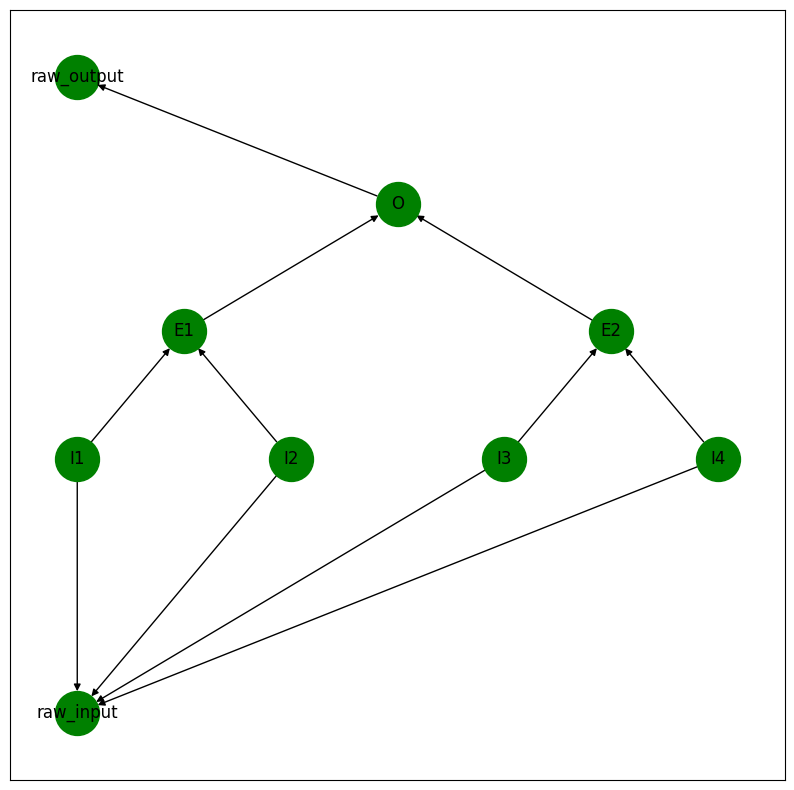

Timesteps: {'I1': 0, 'I2': 0, 'I3': 0, 'I4': 0, 'E1': 1, 'raw_input': 3, 'E2': 1, 'O': 2, 'raw_output': 3}


In [7]:
print_structure(equality_model)
print("Timesteps:", equality_model.timesteps)

### Running the Algorithm: Traces

A **trace** records the values of all variables during a computation. When we provide inputs, the mechanisms compute all derived values and we write $\mathcal{A}(i)$. The code below implements $\mathcal{A}(AABB)$. 

In [8]:
# Run the algorithm on input "AABB"
trace = equality_model.new_trace({"I1": "A", "I2": "A", "I3": "B", "I4": "B"})

print("Input: AABB")
print(f"E1 (I1 == I2): {trace['E1']}")
print(f"E2 (I3 == I4): {trace['E2']}")
print(f"O (E1 == E2): {trace['O']}")

Input: AABB
E1 (I1 == I2): True
E2 (I3 == I4): True
O (E1 == E2): True


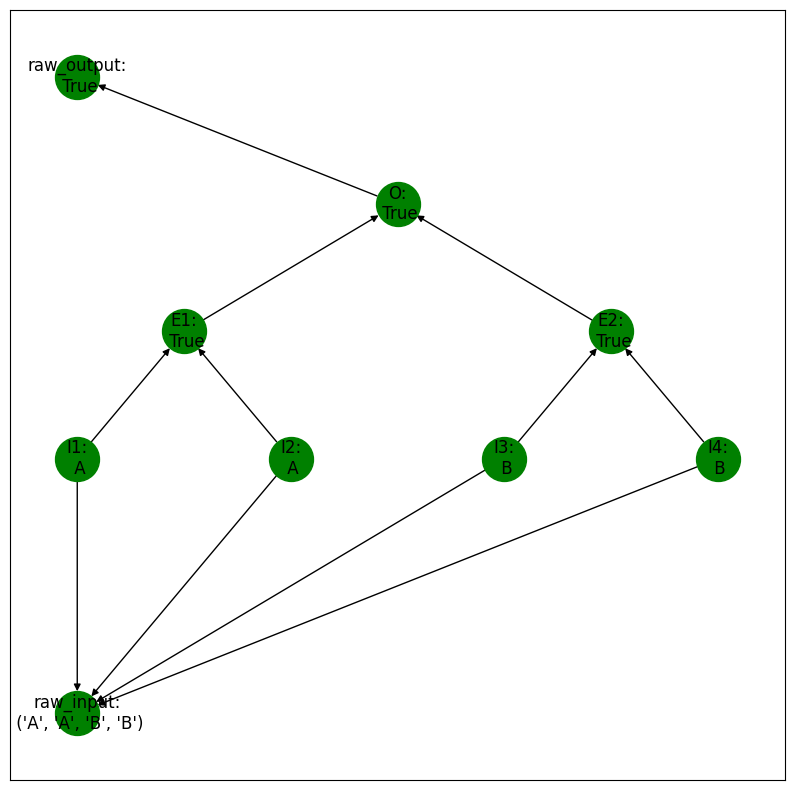

In [9]:
# Visualize the trace
print_setting(equality_model, trace.to_dict())

The code below implements $\mathcal{A}(ABCC)$. 

In [10]:
# Let's try another input: "ABCC"
trace2 = equality_model.new_trace({"I1": "A", "I2": "B", "I3": "C", "I4": "C"})

print("Input: ABCC")
print(f"E1 (I1 == I2): {trace2['E1']}")
print(f"E2 (I3 == I4): {trace2['E2']}")
print(f"O (E1 == E2): {trace2['O']}")

Input: ABCC
E1 (I1 == I2): False
E2 (I3 == I4): True
O (E1 == E2): False


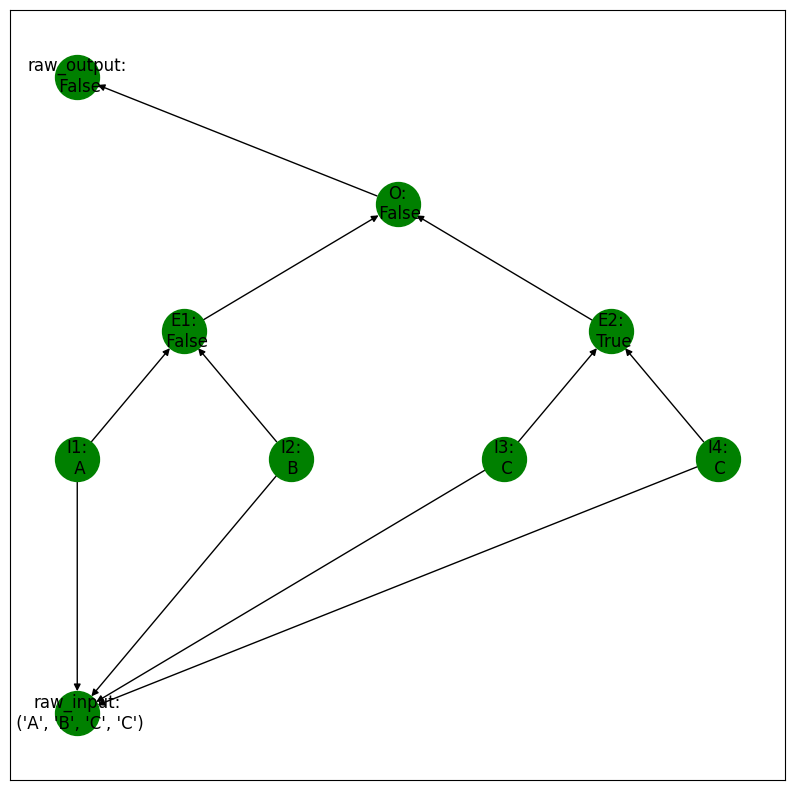

In [11]:
# Visualize the trace
print_setting(equality_model, trace2.to_dict())

### 🧠 Takeaways

- **Causal models** represent algorithms with variables, values, and mechanisms
- The graph structure is a **directed acyclic graph (DAG)**
- **Mechanisms** compute values from parent values
- **Traces** store a value for every variable

### Interchange Interventions on the Algorithm

### What is an Intervention?

An **intervention** (written $\mathcal{A}_{X \leftarrow x}$) forcibly sets a variable $X$ to a specific value $x$, **breaking the causal link from its parents**.

Interventions are the key tool for testing **causal** (not just correlational) relationships.

### Hard Intervention Example

Let's see what happens when we intervene on E1 to compute $\mathcal{A}_{\text{E1} \leftarrow \text{False}}(AABB)$:

In [12]:
# Start with input AABB (normally E1=True, E2=True, O=True)
trace = equality_model.new_trace({"I1": "A", "I2": "A", "I3": "B", "I4": "B"})

print("Before intervention:")
print(f"E1 = {trace['E1']}, E2 = {trace['E2']}, O = {trace['O']}")

Before intervention:
E1 = True, E2 = True, O = True


In [13]:
# Now intervene: force E1 to be False
trace_intervened = equality_model.new_trace({"I1": "A", "I2": "A", "I3": "B", "I4": "B"})
trace_intervened.intervene("E1", False)

print("After intervention do(E1 = False):")
print(f"E1 = {trace_intervened['E1']}, E2 = {trace_intervened['E2']}, O = {trace_intervened['O']}")

After intervention do(E1 = False):
E1 = False, E2 = True, O = False


Notice that even though I1="A" and I2="A" (which would normally make E1=True), the intervention **overrides** this and sets E1=False. The downstream variable O is then computed based on this intervened value.

### Interchanging Variable Values

An **interchange intervention** is a special type of intervention where we set a variable to the value it would have under a *different* input. This is the central technique for causal abstraction analysis.

Given:
- An **original input** $i_{\text{orig}}$
- A **source input** $i_{\text{counter}}$
- A **target variable** $X$

The interchange intervention runs the model on $i_{\text{orig}}$ but sets $X$ to the value it would have when running on $i_{\text{counter}}$:

$$\mathcal{A}(i_{\text{orig}})_{\text{X} \leftarrow \mathcal{A}(i_{\text{counter}})}$$

### Interchange Example

The code below implements $\mathcal{A}(AABB)_{\text{E1} \leftarrow \mathcal{A}(ABCC)}$:

In [14]:
# Base input: AABB (E1=True, E2=True, O=True)
base = equality_model.new_trace({"I1": "A", "I2": "A", "I3": "B", "I4": "B"})
print(f"Base (AABB): E1={base['E1']}, E2={base['E2']}, O={base['O']}")

# Source input: ABCC (E1=False, E2=True, O=False)
source = equality_model.new_trace({"I1": "A", "I2": "B", "I3": "C", "I4": "C"})
print(f"Source (ABCC): E1={source['E1']}, E2={source['E2']}, O={source['O']}")

# Interchange on E1: run base but use E1 value from source
result = equality_model.run_interchange(base, {"E1": source})

print(f"\nInterchange on E1:")
print(f"  E1 = {result['E1']} (from source)")
print(f"  E2 = {result['E2']} (from base)")
print(f"  O = {result['O']} (recomputed)")

Base (AABB): E1=True, E2=True, O=True
Source (ABCC): E1=False, E2=True, O=False

Interchange on E1:
  E1 = False (from source)
  E2 = True (from base)
  O = False (recomputed)


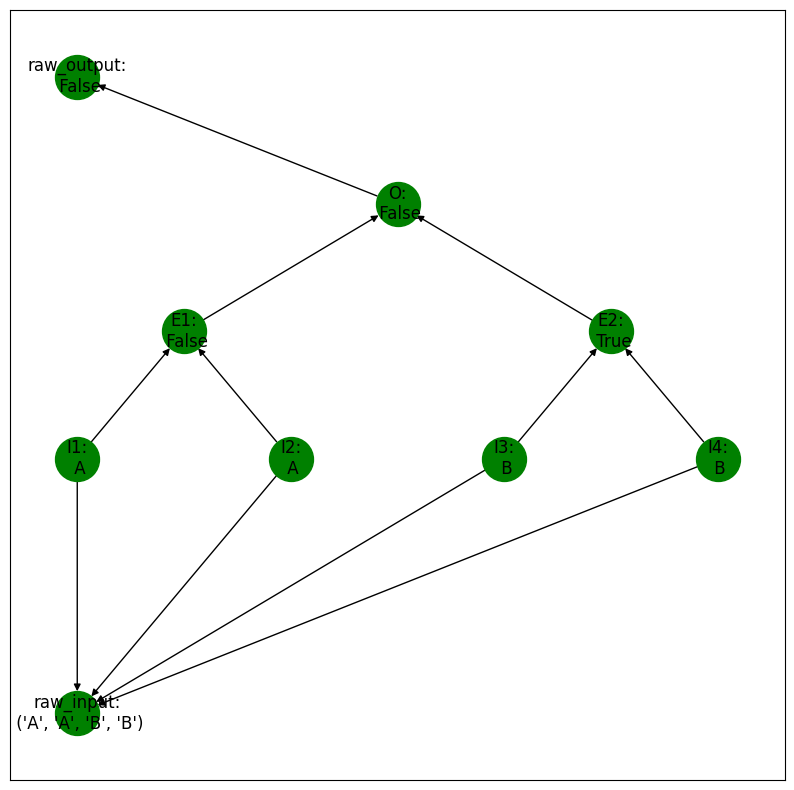

In [15]:
# Visualize the interchange result
print_setting(equality_model, result.to_dict())

### 🧠 Takeaways

- **Interchange interventions** swap values between computations
- Take the value from a *counterfactual* trace and inject it into an *original* computation

## 2️⃣ Neural Networks as Causal Models

Below we define a simple multi-layer perceptron (MLP) neural network that perfectly solves the hierarchical equality task. Just like the algorithm above, **the neural network is a `CausalModel` object** — every neuron is its own causal variable, and every non-zero weight is a causal edge.

The MLP has the following causal variables:

- **X1..X8**: Embedding neurons — X1,X2 = embed(letter1), X3,X4 = embed(letter2), etc. Parents: `raw_input`
- **H1_1..H1_8**: First hidden layer neurons (ReLU activations). Parents determined by non-zero entries in $W_1$.
- **H2_1..H2_8**: Second hidden layer neurons. Parents determined by non-zero entries in $W_2$.
- **Y1, Y2**: Output logits — the final computation layer. Parents determined by non-zero entries in $W_3$. The network's `raw_output` is `bool(Y2 > Y1)`.

The key structural insight: **$W_1$ is block-diagonal**, which means:
- H1_1..H1_4 depend only on X1..X4 (first pair)
- H1_5..H1_8 depend only on X5..X8 (second pair)

This creates two **disconnected subgraphs** in layer 1, directly mirroring the algorithm's $E_1$ and $E_2$. The block-diagonal structure is visible in `print_structure(nn_model)` below.

AABB: prediction=True
  H1_1-H1_4 = [0.0, 0.0, 0.0, 0.0]   H1_5-H1_8 = [0.0, 0.0, 0.0, 0.0]
ABCC: prediction=False
  H1_1-H1_4 = [0.0, np.float64(0.7), np.float64(0.71), 0.0]   H1_5-H1_8 = [0.0, 0.0, 0.0, 0.0]
ABCD: prediction=True
  H1_1-H1_4 = [0.0, np.float64(0.7), np.float64(0.71), 0.0]   H1_5-H1_8 = [np.float64(0.19), 0.0, 0.0, np.float64(1.42)]
AABC: prediction=False
  H1_1-H1_4 = [0.0, 0.0, 0.0, 0.0]   H1_5-H1_8 = [np.float64(1.15), np.float64(0.89), 0.0, 0.0]

Accuracy on {A,B,C,D}^4 (256 inputs): 256/256


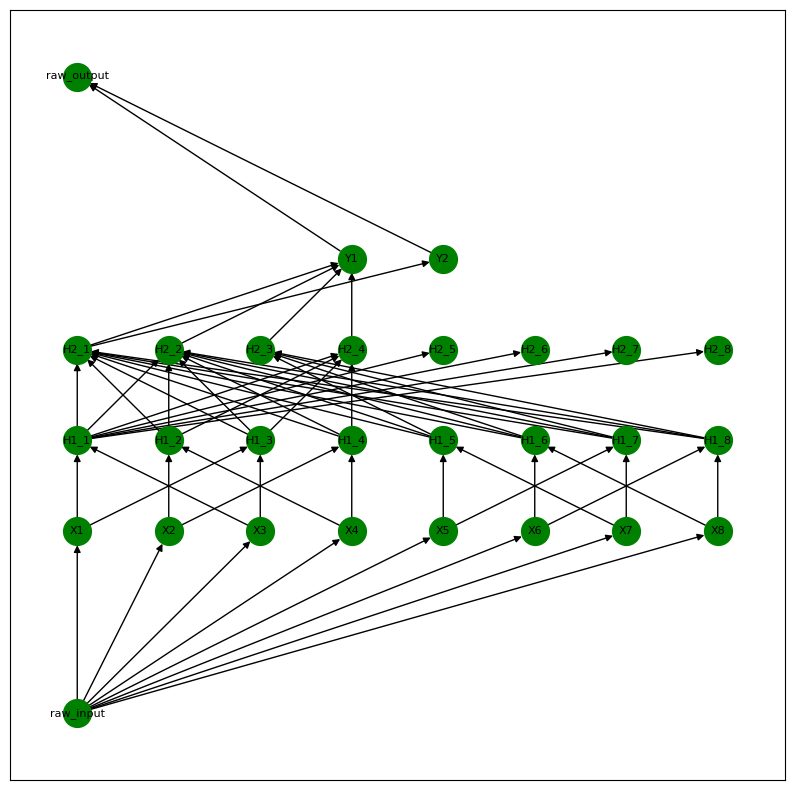

In [16]:
# ---- Embeddings ----
embedding_dim = 2
np.random.seed(42)
letter_embeddings = {
    letter: np.round(np.random.uniform(-1, 1, size=embedding_dim), 2)
    for letter in letters
}

def relu(x):
    return max(0.0, x)

# Layer 1 weights (8x8): componentwise differences between pairs
# BLOCK-DIAGONAL: H1_1-H1_4 depend only on (I1,I2), H1_5-H1_8 only on (I3,I4)
W1 = np.array([
    [ 1,  0, -1,  0,  0,  0,  0,  0],
    [ 0,  1,  0, -1,  0,  0,  0,  0],
    [-1,  0,  1,  0,  0,  0,  0,  0],
    [ 0, -1,  0,  1,  0,  0,  0,  0],
    [ 0,  0,  0,  0,  1,  0, -1,  0],
    [ 0,  0,  0,  0,  0,  1,  0, -1],
    [ 0,  0,  0,  0, -1,  0,  1,  0],
    [ 0,  0,  0,  0,  0, -1,  0,  1],
], dtype=float)

# Layer 2 weights (8x8): L1 norms and their difference
W2 = np.array([
    [ 1,  1,  1,  1, -1, -1, -1, -1],
    [-1, -1, -1, -1,  1,  1,  1,  1],
    [ 0,  0,  0,  0,  1,  1,  1,  1],
    [ 1,  1,  1,  1,  0,  0,  0,  0],
    [ 0,  0,  0,  0,  0,  0,  0,  0],
    [ 0,  0,  0,  0,  0,  0,  0,  0],
    [ 0,  0,  0,  0,  0,  0,  0,  0],
    [ 0,  0,  0,  0,  0,  0,  0,  0],
], dtype=float)

# Output weights (2x8) and bias
W3 = np.array([
    [1, 1, -0.999999, -0.999999, 0, 0, 0, 0],
    [0, 0,  0,         0,        0, 0, 0, 0],
], dtype=float)
b3 = np.array([0.0, 1e-14])

# ---- Build the NN CausalModel programmatically ----
nn_mechanisms = {}
nn_values = {
    "raw_input": [None],
    **{f"X{i+1}": [None] for i in range(8)},
    **{f"H1_{i+1}": [None] for i in range(8)},
    **{f"H2_{i+1}": [None] for i in range(8)},
    "Y1": [None], "Y2": [None],
    "raw_output": [True, False],
}

# raw_input: the 4-letter tuple
nn_mechanisms["raw_input"] = input_var([None])

# X neurons: each extracts one embedding dimension from one letter
for i in range(8):
    letter_idx, dim_idx = i // 2, i % 2
    nn_mechanisms[f"X{i+1}"] = Mechanism(
        parents=["raw_input"],
        compute=lambda t, li=letter_idx, di=dim_idx:
            float(letter_embeddings[t["raw_input"][li]][di]),
    )

# H1 neurons: ReLU(W1[i] @ X), parents = X neurons with non-zero weights
for i in range(8):
    row = W1[i]
    parent_idx = [j for j in range(8) if row[j] != 0]
    parents = [f"X{j+1}" for j in parent_idx]
    nn_mechanisms[f"H1_{i+1}"] = Mechanism(
        parents=parents,
        compute=lambda t, r=row, pi=parent_idx:
            relu(sum(r[j] * t[f"X{j+1}"] for j in pi)),
    )

# H2 neurons: ReLU(W2[i] @ H1), parents = H1 neurons with non-zero weights
for i in range(8):
    row = W2[i]
    parent_idx = [j for j in range(8) if row[j] != 0]
    parents = [f"H1_{j+1}" for j in parent_idx]
    if len(parents) == 0:
        # H2_5..H2_8: constant 0 (trivial parent keeps them in the computation cascade)
        nn_mechanisms[f"H2_{i+1}"] = Mechanism(
            parents=["H1_1"],
            compute=lambda t: 0.0,
        )
    else:
        nn_mechanisms[f"H2_{i+1}"] = Mechanism(
            parents=parents,
            compute=lambda t, r=row, pi=parent_idx:
                relu(sum(r[j] * t[f"H1_{j+1}"] for j in pi)),
        )

# Y neurons: W3[i] @ H2 + b3[i], parents = H2 neurons with non-zero weights
for i, name in enumerate(["Y1", "Y2"]):
    row = W3[i]
    parent_idx = [j for j in range(8) if row[j] != 0]
    parents = [f"H2_{j+1}" for j in parent_idx]
    bias = b3[i]
    if len(parents) == 0:
        # Y2: constant bias (trivial parent keeps it in the computation cascade)
        nn_mechanisms[name] = Mechanism(
            parents=["H2_1"],
            compute=lambda t, b=bias: b,
        )
    else:
        nn_mechanisms[name] = Mechanism(
            parents=parents,
            compute=lambda t, r=row, pi=parent_idx, b=bias:
                sum(r[j] * t[f"H2_{j+1}"] for j in pi) + b,
        )

# raw_output: bool(Y2 > Y1)
nn_mechanisms["raw_output"] = Mechanism(
    parents=["Y1", "Y2"],
    compute=lambda t: bool(t["Y2"] > t["Y1"]),
)

# ---- Layout positions for visualization ----
nn_pos = {
    **{f"X{i+1}": (i, 0) for i in range(8)},
    **{f"H1_{i+1}": (i, 1) for i in range(8)},
    **{f"H2_{i+1}": (i, 2) for i in range(8)},
    "Y1": (3, 3), "Y2": (4, 3),
}

nn_model = CausalModel(nn_mechanisms, nn_values, print_pos=nn_pos, id="mlp")

# ---- Test examples ----
for name in ["AABB", "ABCC", "ABCD", "AABC"]:
    t = nn_model.new_trace({"raw_input": tuple(name)})
    h1_left = [round(t[f"H1_{i+1}"], 3) for i in range(4)]
    h1_right = [round(t[f"H1_{i+1}"], 3) for i in range(4, 8)]
    print(f"{name}: prediction={t['raw_output']}")
    print(f"  H1_1-H1_4 = {h1_left}   H1_5-H1_8 = {h1_right}")

# Exhaustive check on {A,B,C,D}^4
correct = total = 0
for i1 in "ABCD":
    for i2 in "ABCD":
        for i3 in "ABCD":
            for i4 in "ABCD":
                t = nn_model.new_trace({"raw_input": (i1, i2, i3, i4)})
                correct += (t["raw_output"] == ((i1 == i2) == (i3 == i4)))
                total += 1
print(f"\nAccuracy on {{A,B,C,D}}^4 ({total} inputs): {correct}/{total}")

# ---- Visualize the causal structure ----
print_structure(nn_model, font=8, node_size=400)

### Interventions on the Neural Network

In notation, a hard intervention that overrides specific neurons in the network is written:

$$\mathcal{N}(i)_{H_{1,1},\dots,H_{1,4} \leftarrow v_1,\dots,v_4}$$

This forces the first four hidden neurons to take values $v_1, \dots, v_4$ regardless of the input $i$, while all other neurons compute normally from their parents.

In [17]:
# Hard intervention: override H1_1..H1_4 in base (AABB) with values from source (ABCC)
base = nn_model.new_trace({"raw_input": ("A", "A", "B", "B")})
source = nn_model.new_trace({"raw_input": ("A", "B", "C", "C")})

print(f"Base (AABB):   prediction={base['raw_output']}")
h1_base = [round(base[f'H1_{i+1}'], 3) for i in range(4)]
print(f"  H1_1-H1_4 = {h1_base}  (equal pair -> zeros)")
print(f"Source (ABCC): prediction={source['raw_output']}")
h1_source = [round(source[f'H1_{i+1}'], 3) for i in range(4)]
print(f"  H1_1-H1_4 = {h1_source}  (different pair -> nonzero)")

# Intervene: replace H1_1..H1_4 with source values
result = base.copy()
for v in ["H1_1", "H1_2", "H1_3", "H1_4"]:
    result.intervene(v, source[v])

print(f"\nAfter do(H1_1..H1_4 <- source values):")
print(f"  prediction = {result['raw_output']}")
h1_res = [round(result[f'H1_{i+1}'], 3) for i in range(4)]
h1_res_r = [round(result[f'H1_{i+1}'], 3) for i in range(4, 8)]
print(f"  H1_1-H1_4 = {h1_res}  H1_5-H1_8 = {h1_res_r}")
print(f"\nThe prediction flipped from True to False — same as A(AABB)_{{E1<-False}} in Section 1.")

Base (AABB):   prediction=True
  H1_1-H1_4 = [0.0, 0.0, 0.0, 0.0]  (equal pair -> zeros)
Source (ABCC): prediction=False
  H1_1-H1_4 = [0.0, np.float64(0.7), np.float64(0.71), 0.0]  (different pair -> nonzero)

After do(H1_1..H1_4 <- source values):
  prediction = False
  H1_1-H1_4 = [0.0, np.float64(0.7), np.float64(0.71), 0.0]  H1_5-H1_8 = [0.0, 0.0, 0.0, 0.0]

The prediction flipped from True to False — same as A(AABB)_{E1<-False} in Section 1.



### Interchange Interventions on the Neural Network

In notation, an interchange intervention on the network replaces neuron values from a base input with those computed from a counterfactual source input:

$$\mathcal{N}(i_{\text{orig}})_{H_{1,1},\dots,H_{1,4} \leftarrow \mathcal{N}(i_{\text{counter}})}$$

This is the network-level analogue of the algorithm interchange $\mathcal{A}(i_{\text{orig}})_{E_1 \leftarrow \mathcal{A}(i_{\text{counter}})}$ from Section 1 — if the alignment is correct, these two operations should produce matching outputs.

In [18]:
# Interchange intervention using CausalModel API
base = nn_model.new_trace({"raw_input": ("A", "A", "B", "B")})
source = nn_model.new_trace({"raw_input": ("A", "B", "C", "C")})

# Interchange H1_1..H1_4: swap the first-pair neurons
nn_result = nn_model.run_interchange(base, {
    "H1_1": source, "H1_2": source, "H1_3": source, "H1_4": source,
})

print(f"Network interchange (base=AABB, source=ABCC, H1_1..H1_4):")
print(f"  prediction = {nn_result['raw_output']}")
h1_left = [round(nn_result[f'H1_{i+1}'], 3) for i in range(4)]
h1_right = [round(nn_result[f'H1_{i+1}'], 3) for i in range(4, 8)]
print(f"  H1_1-H1_4 = {h1_left}  (from source)")
print(f"  H1_5-H1_8 = {h1_right}  (from base)")

# Compare with algorithm interchange from Section 1
algo_base = equality_model.new_trace({"I1": "A", "I2": "A", "I3": "B", "I4": "B"})
algo_source = equality_model.new_trace({"I1": "A", "I2": "B", "I3": "C", "I4": "C"})
algo_result = equality_model.run_interchange(algo_base, {"E1": algo_source})

print(f"\nAlgorithm interchange (base=AABB, source=ABCC, E1):")
print(f"  O = {algo_result['O']}")
print(f"\nBoth flip the output from True to False — intervening on 4 neurons")
print(f"simultaneously mirrors intervening on E1.")

Network interchange (base=AABB, source=ABCC, H1_1..H1_4):
  prediction = False
  H1_1-H1_4 = [0.0, np.float64(0.7), np.float64(0.71), 0.0]  (from source)
  H1_5-H1_8 = [0.0, 0.0, 0.0, 0.0]  (from base)

Algorithm interchange (base=AABB, source=ABCC, E1):
  O = False

Both flip the output from True to False — intervening on 4 neurons
simultaneously mirrors intervening on E1.


## 3️⃣ Implementation via Causal Abstraction

We have now established that both symbolic algorithms and neural networks can be represented as causal models. This will enable us to define **implementation** in terms of **constructive causal abstraction** where high-level variables can be aligned with sets of low-level variables that they abstract. We will show that the algorithm $\mathcal{A}$ is a constructive causal abstraction of of the network $\mathcal{N}$. 

### Alignments and Translations

To relate the algorithm $\mathcal{A}$ to the network $\mathcal{N}$, we define an **alignment** $(\Pi, \pi)$ consisting of two ingredients:

1. **Aligned sets $\Pi$** — a mapping from each algorithm variable to a *set* of neuron variables:
   - $\Pi_{E_1} = \{\text{H1\_1}, \text{H1\_2}, \text{H1\_3}, \text{H1\_4}\}$
   - $\Pi_{E_2} = \{\text{H1\_5}, \text{H1\_6}, \text{H1\_7}, \text{H1\_8}\}$
   - $\Pi_{O} = \{Y_1, Y_2\}$

2. **Translation maps $\pi_V$** — functions that read the high-level value from the aligned neurons:
   - $\pi_{I_k}$: inverse embedding lookup (find the closest letter from the X neurons)
   - $\pi_{E_k}$: True iff the aligned H1 neurons are all zero (zero activation = equal pair)
   - $\pi_{O}$: bool($Y_2 > Y_1$) — converts logit comparison to boolean

From the alignment $(\Pi, \pi)$, three **derived maps** follow:

- **$\tau_\pi$** (trace translation): translates a full network trace to an algorithm trace by applying each $\pi_V$
- **$\omega_\pi$** (intervention translation): translates a network interchange (a set of neurons) to an algorithm interchange (a single variable)
- **$\rho_\pi$** (input translation): translates an algorithm input to a network input — since the algorithm specifies individual letters but the network takes a `raw_input` tuple, $\rho_\pi$ packs the letters into the format the network expects

The alignment targets the **first hidden layer**, where $E_1$ and $E_2$ are cleanly represented by the block-diagonal structure of $W_1$.

In [19]:
# ---- Alignment: algorithm variable -> set of NN neuron variables ----
alignment = {
    "E1": ["H1_1", "H1_2", "H1_3", "H1_4"],
    "E2": ["H1_5", "H1_6", "H1_7", "H1_8"],
    "O":  ["Y1", "Y2"],
}

# ---- Translation maps pi: NN trace -> algorithm variable value ----
def closest_letter(embedding):
    """Inverse embedding lookup."""
    return min(letter_embeddings, key=lambda l: np.sum(np.abs(letter_embeddings[l] - embedding)))

pi = {
    "I1": lambda t: closest_letter(np.array([t["X1"], t["X2"]])),
    "I2": lambda t: closest_letter(np.array([t["X3"], t["X4"]])),
    "I3": lambda t: closest_letter(np.array([t["X5"], t["X6"]])),
    "I4": lambda t: closest_letter(np.array([t["X7"], t["X8"]])),
    "E1": lambda t: bool(t["H1_1"] + t["H1_2"] + t["H1_3"] + t["H1_4"] == 0),
    "E2": lambda t: bool(t["H1_5"] + t["H1_6"] + t["H1_7"] + t["H1_8"] == 0),
    "O":  lambda t: bool(t["Y2"] > t["Y1"]),
}

# ---- Derived map tau: translate a full network trace to an algorithm trace ----
def tau(nn_trace):
    return {var: fn(nn_trace) for var, fn in pi.items()}

# ---- Derived map omega: translate a network interchange to an algorithm interchange ----
def omega(nn_vars, source_nn_trace):
    """Given a set of NN neuron variables being interchanged, return the algorithm-level intervention."""
    for algo_var, aligned_neurons in alignment.items():
        if sorted(nn_vars) == sorted(aligned_neurons):
            return {algo_var: pi[algo_var](source_nn_trace)}
    return {}

# ---- Derived map rho: translate algorithm input to network input ----
def rho(algo_input):
    """rho_pi: translate algorithm input to network input."""
    return {"raw_input": (algo_input["I1"], algo_input["I2"], algo_input["I3"], algo_input["I4"])}

Let's verify that the derived maps work correctly. For trace translation, we check that translating a network trace matches the algorithm trace:

$$\tau_\pi(\mathcal{N}(\rho_\pi(\text{ABCC}))) \stackrel{?}{=} \mathcal{A}(\text{ABCC})$$

For intervention translation, $\omega_\pi$ should map $\{H1\_1, \dots, H1\_4\}$ back to $E_1$. And $\rho_\pi$ should pack algorithm inputs into the network's `raw_input` format.

In [20]:
# ---- Demo: compare tau(N(rho(ABCC))) with A(ABCC) ----
algo_input = {"I1": "A", "I2": "B", "I3": "C", "I4": "C"}
nn_trace = nn_model.new_trace(rho(algo_input))
translated = tau(nn_trace)
algo = equality_model.new_trace(algo_input)

print("tau(N(rho(ABCC))) vs A(ABCC):")
for var in ["I1", "I2", "I3", "I4", "E1", "E2", "O"]:
    t_val, a_val = translated[var], algo[var]
    match = "match" if t_val == a_val else "MISMATCH"
    print(f"  {var}: tau={t_val}, A={a_val}  [{match}]")

# Demo omega: what algorithm intervention does H1_1..H1_4 interchange correspond to?
source_nn = nn_model.new_trace(rho({"I1": "A", "I2": "B", "I3": "C", "I4": "C"}))
algo_intervention = omega(["H1_1", "H1_2", "H1_3", "H1_4"], source_nn)
print(f"\nomega([H1_1..H1_4], N(ABCC)) = {algo_intervention}")
print("H1_1..H1_4 interchange corresponds to E1 interchange")

# Demo rho: translate algorithm input to network input
print(f"\nrho({{'I1': 'A', 'I2': 'B', 'I3': 'C', 'I4': 'C'}}) = {rho(algo_input)}")

tau(N(rho(ABCC))) vs A(ABCC):
  I1: tau=A, A=A  [match]
  I2: tau=B, A=B  [match]
  I3: tau=C, A=C  [match]
  I4: tau=C, A=C  [match]
  E1: tau=False, A=False  [match]
  E2: tau=True, A=True  [match]
  O: tau=False, A=False  [match]

omega([H1_1..H1_4], N(ABCC)) = {'E1': False}
H1_1..H1_4 interchange corresponds to E1 interchange

rho({'I1': 'A', 'I2': 'B', 'I3': 'C', 'I4': 'C'}) = {'raw_input': ('A', 'B', 'C', 'C')}


### When Does One Model Abstract Another?

Equipped with a $\tau$, a translation from low-level traces to high-level traces, and $\omega$, a translation from low-level interventions to high-level interventions, we can finally define the core requirement of causal abstraction. The idea, originally put forth in [Rubenstein and Weichwald et al. (2017)](https://arxiv.org/abs/1707.00819), is that the high-level trace produced by a high-level intervention translated from a low-level intervention should be the same as the high-level trace produced by translating the low-level trace produced by the low-level intervention.

In a single equation, $\mathcal{H}$ is an abstraction of $\mathcal{L}$ if for all inputs $i$ and all interventions $X \leftarrow x$:

$$\tau_\pi(\textsf{Run}(\mathcal{L}_{X \leftarrow x}(i))) = \textsf{Run}(\mathcal{H}_{\omega_\pi(X \leftarrow x)}(\rho_{\pi}(i)))$$

In other words: **for every input and every intervention, the two models produce the same trace up to translation**.

An insight from [Geiger et al. (2026)](https://arxiv.org/abs/2508.11214) is that **all interchange interventions** appear in $\omega_{\pi}$ by construction (each $\pi_X$ must be defined when the empty intervention is performed, which in turn guarantees that $\omega_{\pi}$ is defined on interchange interventions). 

### Interchange Intervention Accuracy

In practice, we measure alignment quality using **Interchange Intervention Accuracy (IIA)** over a dataset of **base-source input pairs**:

$$\text{IIA} = \frac{1}{|\mathcal{D}|} \sum_{(b, s) \in \mathcal{D}} \mathbf{1}\!\left[\pi_O\!\left(\mathcal{N}(b)_{\Pi_V \leftarrow \mathcal{N}(s)}\right) = \mathcal{A}(\rho(b))_{V \leftarrow \mathcal{A}(\rho(s))}\right]

$$

Where:
- $\mathcal{D}$ is a dataset of (base, source) pairs
- $V$ is the algorithm variable being tested (e.g., $E_1$)
- $\Pi_V$ are the neurons aligned with $V$ (e.g., $H_1$-$H_4$)

**IIA = 1.0 means perfect causal abstraction** — for every base-source pair, the translated network interchange matches the algorithm interchange. For a hand-crafted network built to implement the algorithm, we expect IIA = 1.0 under the correct alignment and IIA < 1.0 under a wrong alignment.

In [21]:
import itertools

# Generate (base, source) pairs from {A,B,C,D}^4
test_inputs = list(itertools.product("ABCD", repeat=4))
random.seed(42)
pairs = random.sample(list(itertools.product(test_inputs, test_inputs)), 500)

def compute_iia(pairs, nn_vars, algo_var):
    """Compute IIA: fraction of pairs where network and algorithm interchanges agree."""
    correct = 0
    for base_letters, source_letters in pairs:
        algo_base_input = dict(zip(["I1","I2","I3","I4"], base_letters))
        algo_source_input = dict(zip(["I1","I2","I3","I4"], source_letters))

        # Network interchange at aligned neurons
        nn_base = nn_model.new_trace(rho(algo_base_input))
        nn_source = nn_model.new_trace(rho(algo_source_input))
        nn_result = nn_model.run_interchange(nn_base, {v: nn_source for v in nn_vars})

        # Algorithm interchange at aligned variable
        algo_base = equality_model.new_trace(algo_base_input)
        algo_source = equality_model.new_trace(algo_source_input)
        algo_result = equality_model.run_interchange(algo_base, {algo_var: algo_source})

        if pi["O"](nn_result) == algo_result["O"]:
            correct += 1
    return correct / len(pairs)

# ---- Correct alignments ----
print("Correct alignments:")
print(f"  IIA(E1 -> H1_1..H1_4) = {compute_iia(pairs, ['H1_1','H1_2','H1_3','H1_4'], 'E1'):.3f}")
print(f"  IIA(E2 -> H1_5..H1_8) = {compute_iia(pairs, ['H1_5','H1_6','H1_7','H1_8'], 'E2'):.3f}")

# ---- Wrong alignments ----
print("\nWrong alignments:")
print(f"  IIA(E1 -> H1_1,H1_2,H1_7, H1_4) = {compute_iia(pairs, ['H1_1','H1_2','H1_7','H1_4'], 'E1'):.3f}")
print(f"  IIA(E2 -> H1_5,H1_6,H1_3,H1_8) = {compute_iia(pairs, ['H1_5','H1_6','H1_3','H1_8'], 'E2'):.3f}")

print("\nThe correct alignment achieves IIA = 1.0 (perfect causal abstraction).")
print("The wrong alignment fails — IIA is sensitive to actual computational structure.")

Correct alignments:
  IIA(E1 -> H1_1..H1_4) = 1.000
  IIA(E2 -> H1_5..H1_8) = 1.000

Wrong alignments:
  IIA(E1 -> H1_1,H1_2,H1_7, H1_4) = 0.850
  IIA(E2 -> H1_5,H1_6,H1_3,H1_8) = 0.826

The correct alignment achieves IIA = 1.0 (perfect causal abstraction).
The wrong alignment fails — IIA is sensitive to actual computational structure.


### 🧠 Takeaways

- **Causal abstraction** holds when the algorithm $\mathcal{A}$ and network $\mathcal{N}$ agree on all counterfactual behaviors
- The core equation: $\tau(\mathcal{N}_{X \leftarrow x}(i)) = \mathcal{A}_{\omega(X \leftarrow x)}(i)$
- **Alignment** maps each algorithm variable to a *set* of neuron variables in the network
- **Translation functions** ($\pi$, $\tau$, $\omega$) map between levels
- **IIA = 1.0** under the correct alignment confirms that the algorithm is implemented by the network

### Beyond IIA

IIA is one metric among many for evaluating causal abstraction. When the output of the model is a probability distribution rather than a discrete prediction, **KL divergence** provides a natural continuous alternative. The **KL-IIA** score replaces the binary match with an information-theoretic measure of divergence:

$$\text{KL-IIA} = 1 - \frac{1}{|\mathcal{D}|} \sum_{(b, s) \in \mathcal{D}} D_{\text{KL}}\!\left(\, \mathcal{A}(\rho(b))_{V \leftarrow \mathcal{A}(\rho(s))} \;\|\; \pi_O\!\left(\mathcal{N}(b)_{\Pi_V \leftarrow \mathcal{N}(s)}\right) \right)$$

KL-IIA equals 1.0 when the distributions match exactly and decreases as they diverge. For deterministic models like our MLP (which outputs a hard True/False), IIA and KL-IIA coincide, but for models with soft outputs (e.g., language model logits), KL-IIA captures graded alignment that binary accuracy misses.